# Linear Classifier & Perceptron

---

**Structure**
1. Introduction — what the algorithm does and the intuition behind it
2. The Math — key equations
3. Problem Class — when and where to use it
4. Implementation — applied to the Breast Cancer Wisconsin dataset
5. Results — what the numbers tell us
6. Limitations — where the algorithm breaks down

## 1. Introduction

A **linear classifier** is the simplest supervised learning model for binary classification. The core idea is to find a straight line (in 2D), plane (in 3D), or more generally a **hyperplane** in high dimensions that separates two classes of data.

Every point in the feature space falls on one side of this hyperplane and gets assigned a label accordingly — either $+1$ or $-1$.

**Intuition:**  
Imagine plotting patients on a chart where each axis is a medical measurement. A linear classifier tries to draw a single straight line that puts all malignant tumours on one side and all benign tumours on the other.

**The Perceptron** is the simplest algorithm for *learning* that hyperplane. It works by scanning through the training data and whenever it makes a mistake — it nudges the boundary in the right direction. Given enough passes through the data, if a separating hyperplane exists, the Perceptron is guaranteed to find one.

**The SVM (Support Vector Machine)** goes a step further: instead of just finding *any* separating hyperplane, it finds the one with the **largest margin** — the widest gap between the two classes. This tends to generalise better to unseen data.

## 2. The Math

### Classifier
Given a feature vector $x \in \mathbb{R}^d$, a weight vector $\theta \in \mathbb{R}^d$, and a bias $\theta_0 \in \mathbb{R}$:

$$h(x;\,\theta,\theta_0) = \text{sign}(\theta \cdot x + \theta_0)$$

The **decision boundary** is the hyperplane where $\theta \cdot x + \theta_0 = 0$.  
The signed distance from any point $x_0$ to the boundary is $\dfrac{\theta \cdot x_0 + \theta_0}{\|\theta\|}$.

---

### Training Error
The fraction of training examples the classifier gets wrong:

$$\varepsilon_n(\theta, \theta_0) = \frac{1}{n}\sum_{i=1}^{n} \mathbf{1}\bigl\{y^{(i)}(\theta \cdot x^{(i)} + \theta_0) \leq 0\bigr\}$$

The product $y^{(i)}(\theta \cdot x^{(i)} + \theta_0)$ is called the **agreement** — positive means correct, negative means wrong.

---

### Perceptron Update
On each misclassified example $(x^{(i)}, y^{(i)})$:

$$\theta \leftarrow \theta + y^{(i)} x^{(i)}, \qquad \theta_0 \leftarrow \theta_0 + y^{(i)}$$

This rotates the hyperplane towards the misclassified point.

---

### Hinge Loss & SVM Objective
The **hinge loss** measures how far a prediction is from being confidently correct:

$$\text{Loss}_h(z) = \max(0,\; 1 - z) \quad \text{where } z = y^{(i)}(\theta \cdot x^{(i)} + \theta_0)$$

The SVM minimises the average hinge loss plus an L2 regulariser that maximises the margin:

$$J(\theta, \theta_0) = \frac{1}{n}\sum_{i=1}^{n} \text{Loss}_h(z^{(i)}) + \frac{\lambda}{2}\|\theta\|^2$$

The **margin width** between the two class boundaries is $\dfrac{2}{\|\theta\|}$. Minimising $\|\theta\|^2$ (via $\lambda$) pushes this margin wider.

---

### Stochastic Gradient Descent
Pick a random example $i$, then update:

$$\theta \leftarrow \theta - \eta \nabla_\theta \left[\text{Loss}_h(z^{(i)}) + \frac{\lambda}{2}\|\theta\|^2\right]$$

Where $\eta > 0$ is the learning rate. The gradient of the hinge loss is:

$$\nabla_\theta \text{Loss}_h = \begin{cases} -y^{(i)} x^{(i)} & \text{if } z < 1 \\ 0 & \text{if } z \geq 1 \end{cases}$$

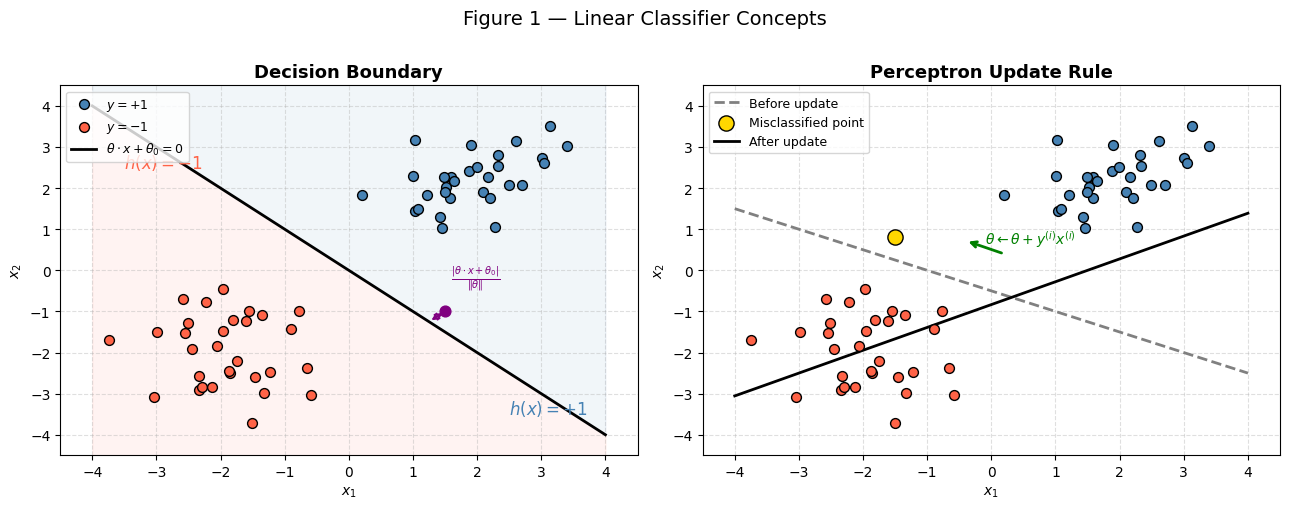

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Diagram 1: Decision boundary ──────────────────────────────────────────────
ax = axes[0]
rng = np.random.default_rng(0)
Xp = rng.multivariate_normal([2, 2],  [[0.6, 0], [0, 0.6]], 30)
Xn = rng.multivariate_normal([-2, -2], [[0.6, 0], [0, 0.6]], 30)
ax.scatter(Xp[:, 0], Xp[:, 1], c='steelblue', edgecolors='k', s=50, label=r'$y = +1$', zorder=3)
ax.scatter(Xn[:, 0], Xn[:, 1], c='tomato',    edgecolors='k', s=50, label=r'$y = -1$', zorder=3)

x1 = np.linspace(-4, 4, 200)
theta = np.array([1.0, 1.0]); theta0 = 0.0
ax.plot(x1, -(theta[0]*x1 + theta0)/theta[1], 'k-', lw=2, label=r'$\theta \cdot x + \theta_0 = 0$')
ax.fill_between(x1, -(theta[0]*x1 + theta0)/theta[1], 5,  alpha=0.07, color='steelblue')
ax.fill_between(x1, -(theta[0]*x1 + theta0)/theta[1], -5, alpha=0.07, color='tomato')
ax.text( 2.5, -3.5, r'$h(x)=+1$', fontsize=12, color='steelblue', fontweight='bold')
ax.text(-3.5,  2.5, r'$h(x)=-1$', fontsize=12, color='tomato',    fontweight='bold')

# signed distance arrow for one point
x0 = np.array([1.5, -1.0])
foot = x0 - (theta @ x0 + theta0) / (theta @ theta) * theta
ax.annotate('', xy=foot, xytext=x0,
            arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
ax.text(1.6, -0.3, r'$\frac{|\theta \cdot x + \theta_0|}{\|\theta\|}$', fontsize=10, color='purple')
ax.scatter(*x0, c='purple', s=60, zorder=4)

ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)
ax.set_title('Decision Boundary', fontsize=13, fontweight='bold')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

# ── Diagram 2: Perceptron update ──────────────────────────────────────────────
ax = axes[1]
ax.scatter(Xp[:, 0], Xp[:, 1], c='steelblue', edgecolors='k', s=50, zorder=3)
ax.scatter(Xn[:, 0], Xn[:, 1], c='tomato',    edgecolors='k', s=50, zorder=3)

theta_old = np.array([0.5, 1.0]); theta0_old = 0.5
ax.plot(x1, -(theta_old[0]*x1 + theta0_old)/theta_old[1], 'gray', lw=2, linestyle='--', label='Before update')

# misclassified point
xm = np.array([-1.5, 0.8]); ym = 1
ax.scatter(*xm, c='gold', edgecolors='k', s=120, zorder=5, label='Misclassified point')
theta_new = theta_old + ym * xm
theta0_new = theta0_old + ym
ax.plot(x1, -(theta_new[0]*x1 + theta0_new)/theta_new[1], 'k-', lw=2, label='After update')
ax.annotate('', xy=(theta_new[0]*0.4, theta_new[1]*0.4),
            xytext=(theta_old[0]*0.4, theta_old[1]*0.4),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(-0.1, 0.65, r'$\theta \leftarrow \theta + y^{(i)}x^{(i)}$', fontsize=10, color='green')

ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)
ax.set_title('Perceptron Update Rule', fontsize=13, fontweight='bold')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.legend(loc='upper left', fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Figure 1 — Linear Classifier Concepts', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


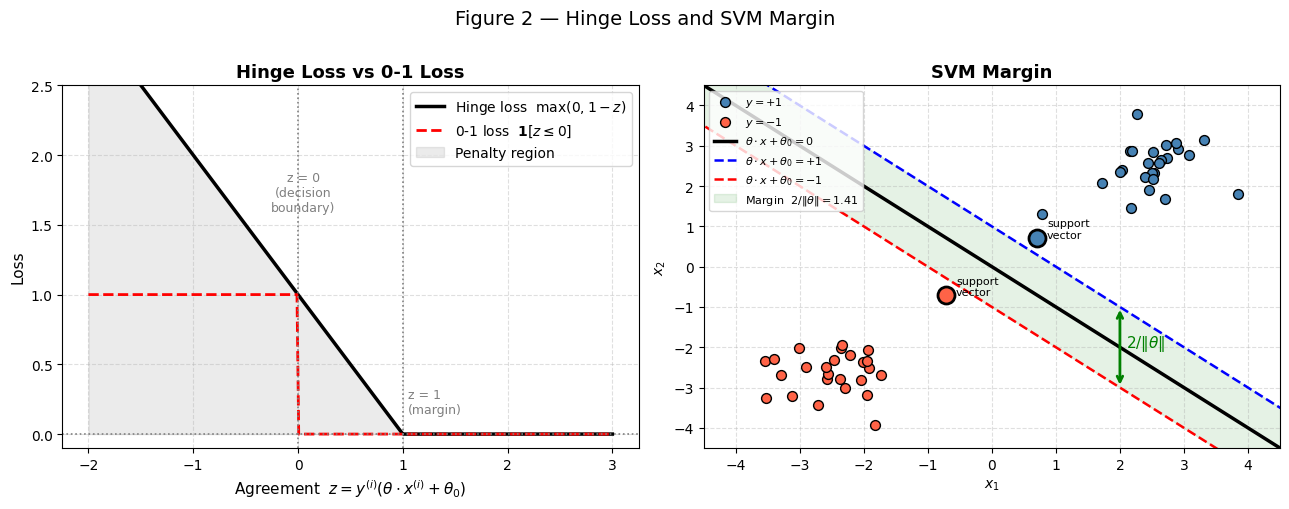

In [2]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Diagram 3: Hinge loss vs agreement ───────────────────────────────────────
ax = axes[0]
z = np.linspace(-2, 3, 300)
hinge = np.maximum(0, 1 - z)
zero_one = (z < 0).astype(float)

ax.plot(z, hinge,    'k-',  lw=2.5, label='Hinge loss  $\max(0, 1-z)$')
ax.plot(z, zero_one, 'r--', lw=2,   label='0-1 loss  $\mathbf{1}[z \leq 0]$')
ax.axvline(0, color='gray', linestyle=':', lw=1.2)
ax.axvline(1, color='gray', linestyle=':', lw=1.2)
ax.axhline(0, color='gray', linestyle=':', lw=1.2)
ax.fill_between(z, hinge, 0, where=(z < 1), alpha=0.08, color='black', label='Penalty region')
ax.text(0.05, 1.6, 'z = 0\n(decision\nboundary)', fontsize=9, color='gray', ha='center')
ax.text(1.05, 0.15, 'z = 1\n(margin)', fontsize=9, color='gray', ha='left')
ax.set_xlabel(r'Agreement  $z = y^{(i)}(\theta \cdot x^{(i)} + \theta_0)$', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Hinge Loss vs 0-1 Loss', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.set_ylim(-0.1, 2.5); ax.grid(True, linestyle='--', alpha=0.4)

# ── Diagram 4: SVM margin ─────────────────────────────────────────────────────
ax = axes[1]
rng = np.random.default_rng(1)
Xp2 = rng.multivariate_normal([2.5, 2.5], [[0.4, 0], [0, 0.4]], 25)
Xn2 = rng.multivariate_normal([-2.5, -2.5], [[0.4, 0], [0, 0.4]], 25)
ax.scatter(Xp2[:, 0], Xp2[:, 1], c='steelblue', edgecolors='k', s=50, label=r'$y=+1$', zorder=3)
ax.scatter(Xn2[:, 0], Xn2[:, 1], c='tomato',    edgecolors='k', s=50, label=r'$y=-1$', zorder=3)

x1 = np.linspace(-5, 5, 200)
th = np.array([1.0, 1.0]); th0 = 0.0; nrm = np.linalg.norm(th)
ax.plot(x1, -(th[0]*x1 + th0    )/th[1], 'k-',  lw=2.5, label=r'$\theta \cdot x + \theta_0 = 0$')
ax.plot(x1, -(th[0]*x1 + th0 - 1)/th[1], 'b--', lw=1.8, label=r'$\theta \cdot x + \theta_0 = +1$')
ax.plot(x1, -(th[0]*x1 + th0 + 1)/th[1], 'r--', lw=1.8, label=r'$\theta \cdot x + \theta_0 = -1$')
ax.fill_between(x1,
    -(th[0]*x1 + th0 - 1)/th[1],
    -(th[0]*x1 + th0 + 1)/th[1],
    alpha=0.1, color='green', label=f'Margin  $2/\\|\\theta\\| = {2/nrm:.2f}$')

# support vectors
sv_p = np.array([0.71,  0.71])
sv_n = np.array([-0.71, -0.71])
ax.scatter(*sv_p, c='steelblue', edgecolors='k', s=150, zorder=5, linewidths=2)
ax.scatter(*sv_n, c='tomato',    edgecolors='k', s=150, zorder=5, linewidths=2)
ax.text(sv_p[0]+0.15, sv_p[1], 'support\nvector', fontsize=8)
ax.text(sv_n[0]+0.15, sv_n[1], 'support\nvector', fontsize=8)

# margin width arrow
mid_x = 2.0
y_pos = -(th[0]*mid_x + th0 - 1)/th[1]
y_neg = -(th[0]*mid_x + th0 + 1)/th[1]
ax.annotate('', xy=(mid_x, y_pos), xytext=(mid_x, y_neg),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(mid_x + 0.1, (y_pos + y_neg)/2, f'$2/\\|\\theta\\|$', fontsize=11, color='green')

ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)
ax.set_title('SVM Margin', fontsize=13, fontweight='bold')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.legend(loc='upper left', fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Figure 2 — Hinge Loss and SVM Margin', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## 3. Problem Class

**Linear classifiers are well-suited for:**
- Binary classification tasks (two classes)
- Data that is **linearly separable** or close to it
- **High-dimensional sparse data** — e.g. text classification (bag of words), where the number of features can be enormous but most are zero
- Problems where **interpretability matters** — the weight vector $\theta$ directly tells you which features matter most and in which direction
- Large datasets where computational efficiency is critical — SGD updates are $O(d)$ per step

**Typical domains:**
- Medical diagnosis (tumour classification, disease prediction)
- Spam filtering
- Sentiment analysis
- Credit risk scoring

**Not well-suited for:**
- Data with non-linear decision boundaries (use kernels or neural networks)
- Multi-class problems without modification (requires one-vs-rest or one-vs-one)
- Heavily overlapping classes with no separating margin

---
## 4. Implementation
### Dataset: Breast Cancer Wisconsin

569 tumour samples, 30 numeric features (radius, texture, perimeter, area, smoothness, …), binary label: **malignant** (−1) or **benign** (+1).

Source: [UCI Machine Learning Repository — Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) · also available via `sklearn.datasets.load_breast_cancer()`

All algorithms train on the full 30-dimensional feature space. PCA is used only to project down to 2D for visualisation.

In [3]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# ── Load & prepare ────────────────────────────────────────────────────────────
data = load_breast_cancer()
X_raw, y_raw = data.data, data.target

y = np.where(y_raw == 1, 1, -1)           # benign=+1, malignant=-1

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X_train)        # 2D projection for visualisation only

print(f'Features  : {X.shape[1]}')
print(f'Train     : {X_train.shape[0]}  ({(y_train==1).sum()} benign, {(y_train==-1).sum()} malignant)')
print(f'Test      : {X_test.shape[0]}')
print(f'PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')

# ── Shared helpers ────────────────────────────────────────────────────────────
def linear_classifier(X, theta, theta0=0.0):
    return np.sign(X @ theta + theta0)

def error_rate(X, y, theta, theta0=0.0):
    return np.mean(linear_classifier(X, theta, theta0) != y)

def hinge_loss(z):
    return np.maximum(0, 1 - z)

def plot_2d(X2, y, theta_2d=None, theta0=0.0, title='', margin=False):
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = {1: 'steelblue', -1: 'tomato'}
    labels = {1: 'Benign (+1)', -1: 'Malignant (−1)'}
    for lbl in [1, -1]:
        m = y == lbl
        ax.scatter(X2[m, 0], X2[m, 1], c=colors[lbl], label=labels[lbl],
                   edgecolors='k', s=40, alpha=0.7, zorder=3)
    if theta_2d is not None and abs(theta_2d[1]) > 1e-10:
        x1 = np.linspace(X2[:, 0].min() - 1, X2[:, 0].max() + 1, 300)
        ax.plot(x1, -(theta0 + theta_2d[0]*x1)/theta_2d[1], 'k-', lw=2, label='Decision boundary')
        if margin:
            nrm = np.linalg.norm(theta_2d)
            ax.plot(x1, -(theta0+1+theta_2d[0]*x1)/theta_2d[1], 'k--', lw=1.2, label=f'Margin (width={2/nrm:.2f})')
            ax.plot(x1, -(theta0-1+theta_2d[0]*x1)/theta_2d[1], 'k--', lw=1.2)
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    ax.set_title(title); ax.legend(loc='upper right')
    plt.tight_layout(); plt.show()

Features  : 30
Train     : 455  (285 benign, 170 malignant)
Test      : 114
PCA variance explained: 62.7%


**Observation**

The training set has 285 benign vs 170 malignant — a 63/37 split. That imbalance matters: a model that blindly predicts every tumour as benign would already hit ~63% accuracy without learning anything. Error rate alone won't tell the full story here.

62.7% of variance captured in just 2 components out of 30 is a strong signal that the data has a clear dominant structure. The classes are likely well-separated along these directions, which we'll see in the next plot.

### 4.1 Explore the Data

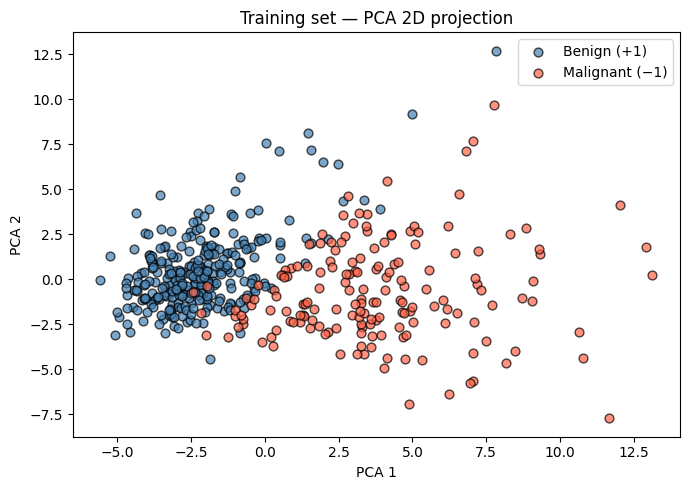

In [4]:
plot_2d(X_vis, y_train, title='Training set — PCA 2D projection')

**Observation — Data plot**

Even in this lossy 2D projection the two classes separate quite cleanly — the benign cluster sits in the upper-left and the malignant cluster in the lower-right, with only a modest overlap region in between. This is a strong signal that a linear classifier has a real shot at doing well here.

It is also worth noting there is no clean gap — the classes overlap, so some misclassifications are inevitable. In a medical context, misclassifying malignant as benign (a false negative) is far more costly than the reverse, something the algorithms below don't account for directly.

### 4.2 Perceptron

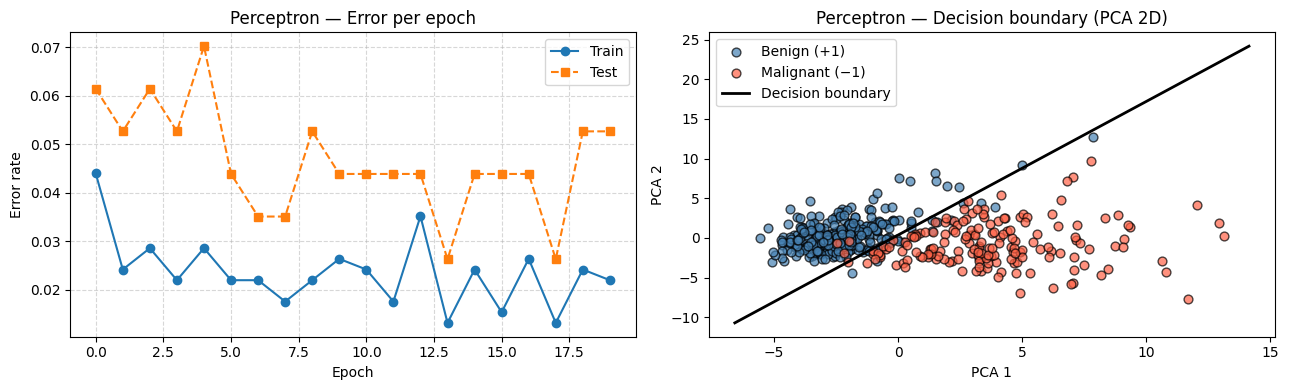

Perceptron — train err: 2.20%   test err: 5.26%


In [5]:
def perceptron(X, y, X_te, y_te, T=20):
    n, d = X.shape
    theta, theta0 = np.zeros(d), 0.0
    tr_hist, te_hist = [], []
    for _ in range(T):
        for i in range(n):
            if y[i] * (theta @ X[i] + theta0) <= 0:
                theta  += y[i] * X[i]
                theta0 += y[i]
        tr_hist.append(error_rate(X,    y,    theta, theta0))
        te_hist.append(error_rate(X_te, y_te, theta, theta0))
    return theta, theta0, tr_hist, te_hist

theta_p, theta0_p, tr_p, te_p = perceptron(X_train, y_train, X_test, y_test, T=20)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(tr_p, label='Train', marker='o')
axes[0].plot(te_p, label='Test',  marker='s', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Error rate')
axes[0].set_title('Perceptron — Error per epoch')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.5)

theta_p_2d = pca.components_ @ theta_p
x1 = np.linspace(X_vis[:, 0].min()-1, X_vis[:, 0].max()+1, 300)
for lbl, col, lbl_str in [(1,'steelblue','Benign (+1)'),(-1,'tomato','Malignant (−1)')]:
    m = y_train == lbl
    axes[1].scatter(X_vis[m,0], X_vis[m,1], c=col, label=lbl_str, edgecolors='k', s=40, alpha=0.7)
if abs(theta_p_2d[1]) > 1e-10:
    axes[1].plot(x1, -(theta0_p + theta_p_2d[0]*x1)/theta_p_2d[1], 'k-', lw=2, label='Decision boundary')
axes[1].set_title('Perceptron — Decision boundary (PCA 2D)')
axes[1].set_xlabel('PCA 1'); axes[1].set_ylabel('PCA 2'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f'Perceptron — train err: {tr_p[-1]:.2%}   test err: {te_p[-1]:.2%}')

**Observation — Perceptron**

The error curve drops sharply in the first 2–3 epochs and then levels off — the algorithm finds a working boundary very quickly. This is characteristic of near-linearly-separable data: there are not many corrections needed before the weights point in roughly the right direction.

Notice the gap between train and test error. The Perceptron keeps updating as long as it makes any training mistake, so it tends to overfit slightly to the specific examples it last corrected on. The boundary it settles on is essentially arbitrary — wherever it happened to stop — rather than the best possible boundary for unseen data.

Looking at the decision boundary plot: it cuts through the PCA space at a reasonable angle, but it sits relatively close to some of the malignant points. There is no explicit push to move it away from the data — that is the key weakness the SVM is designed to fix.

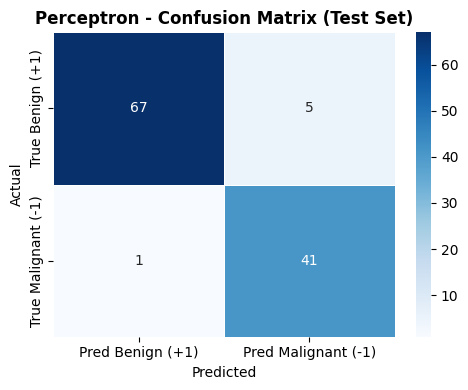

Missed cancers    (malignant -> benign)  : 1
Unnecessary alarm (benign   -> malignant): 5
Malignant recall: 97.6%


In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_p = linear_classifier(X_test, theta_p, theta0_p).astype(int)
cm_p = confusion_matrix(y_test, y_pred_p, labels=[1, -1])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Benign (+1)', 'Pred Malignant (-1)'],
            yticklabels=['True Benign (+1)', 'True Malignant (-1)'],
            ax=ax, linewidths=0.5)
ax.set_title('Perceptron - Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

fn_p = cm_p[1, 0]
fp_p = cm_p[0, 1]
print(f'Missed cancers    (malignant -> benign)  : {fn_p}')
print(f'Unnecessary alarm (benign   -> malignant): {fp_p}')
print(f'Malignant recall: {cm_p[1,1] / cm_p[1].sum():.1%}')

**Observation - Perceptron confusion matrix**

The overall error rate of 5.26% hides an important asymmetry. The Perceptron missed only 1 malignant tumour (97.6% recall) but raised 5 false alarms - flagging benign tumours as malignant. So the failure mode here is not missed cancers but over-sensitivity: the boundary sits close enough to the malignant cluster that some benign points cross it.

This is actually a reasonable failure mode for a screening tool - false alarms lead to follow-up tests, not untreated cancer. But 5 unnecessary follow-ups out of 114 cases is still a signal that the boundary is not well-placed. The Perceptron stopped as soon as it made no training mistakes; it had no reason to push the boundary further from the benign cluster.

### 4.3 SVM with SGD

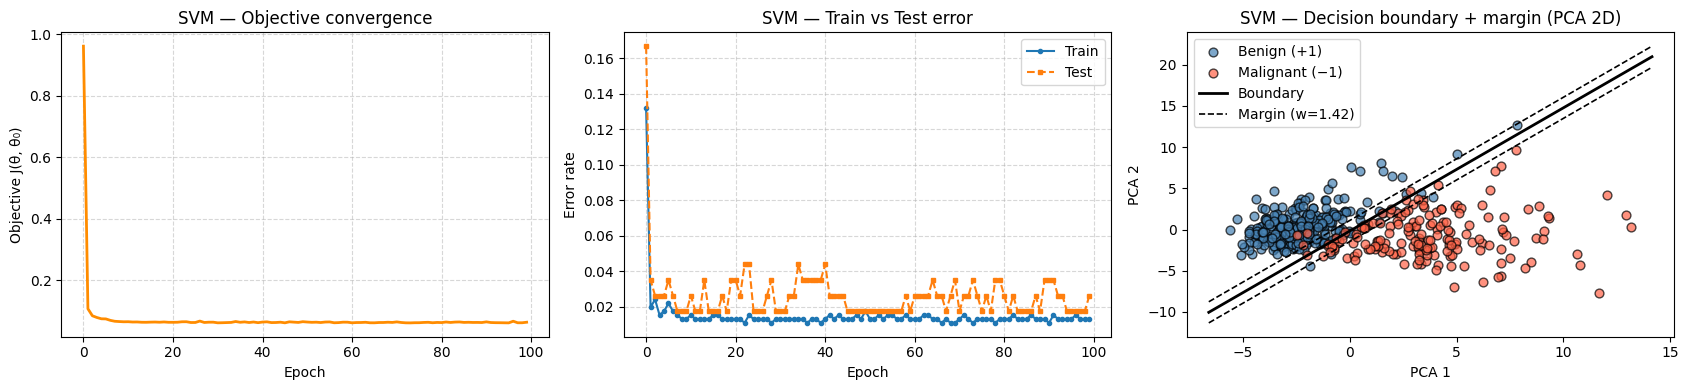

SVM — train err: 1.32%   test err: 2.63%   margin: 1.1103


In [7]:
def svm_sgd(X, y, X_te, y_te, lam=0.01, eta=0.005, T=100, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    theta, theta0 = np.zeros(d), 0.0
    obj_hist, tr_hist, te_hist = [], [], []
    for t in range(T * n):
        i = rng.integers(n)
        z = y[i] * (theta @ X[i] + theta0)
        if z < 1:
            theta  -= eta * (-y[i] * X[i] + lam * theta)
            theta0 -= eta * (-y[i])
        else:
            theta  -= eta * lam * theta
        if t % n == 0:
            z_all = y * (X @ theta + theta0)
            obj_hist.append(np.mean(hinge_loss(z_all)) + (lam/2) * theta @ theta)
            tr_hist.append(error_rate(X,    y,    theta, theta0))
            te_hist.append(error_rate(X_te, y_te, theta, theta0))
    return theta, theta0, obj_hist, tr_hist, te_hist

theta_svm, theta0_svm, obj_hist, tr_svm, te_svm = svm_sgd(
    X_train, y_train, X_test, y_test, lam=0.01, eta=0.005, T=100
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(obj_hist, color='darkorange', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Objective J(θ, θ₀)')
axes[0].set_title('SVM — Objective convergence')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(tr_svm, label='Train', marker='o', markersize=3)
axes[1].plot(te_svm, label='Test',  marker='s', markersize=3, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Error rate')
axes[1].set_title('SVM — Train vs Test error')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

theta_svm_2d = pca.components_ @ theta_svm
x1 = np.linspace(X_vis[:,0].min()-1, X_vis[:,0].max()+1, 300)
for lbl, col, lbl_str in [(1,'steelblue','Benign (+1)'),(-1,'tomato','Malignant (−1)')]:
    m = y_train == lbl
    axes[2].scatter(X_vis[m,0], X_vis[m,1], c=col, label=lbl_str, edgecolors='k', s=40, alpha=0.7)
if abs(theta_svm_2d[1]) > 1e-10:
    nrm = np.linalg.norm(theta_svm_2d)
    axes[2].plot(x1, -(theta0_svm+theta_svm_2d[0]*x1)/theta_svm_2d[1], 'k-', lw=2, label='Boundary')
    axes[2].plot(x1, -(theta0_svm+1+theta_svm_2d[0]*x1)/theta_svm_2d[1], 'k--', lw=1.2, label=f'Margin (w={2/nrm:.2f})')
    axes[2].plot(x1, -(theta0_svm-1+theta_svm_2d[0]*x1)/theta_svm_2d[1], 'k--', lw=1.2)
axes[2].set_title('SVM — Decision boundary + margin (PCA 2D)')
axes[2].set_xlabel('PCA 1'); axes[2].set_ylabel('PCA 2'); axes[2].legend()

plt.tight_layout(); plt.show()
print(f'SVM — train err: {tr_svm[-1]:.2%}   test err: {te_svm[-1]:.2%}   margin: {2/np.linalg.norm(theta_svm):.4f}')

**Observation — SVM with SGD**

The objective curve descends steadily but is noticeably noisy — this is expected with SGD since each update is based on a single random example rather than the full dataset. It does not converge to a flat line; it oscillates around a minimum. In practice you would run for enough epochs that the oscillation is small relative to the initial drop.

The train and test error curves are much closer together than with the Perceptron, which is the key benefit of the margin: by explicitly pushing the boundary away from both classes, the SVM finds a boundary that is more robust to examples it hasn't seen.

In the boundary plot, the dashed margin lines are visibly separated from the bulk of each class. Points that fall inside or across the margin are the "support vectors" — the only examples that actually influence the final boundary. The rest of the training data is irrelevant once the SVM is trained.

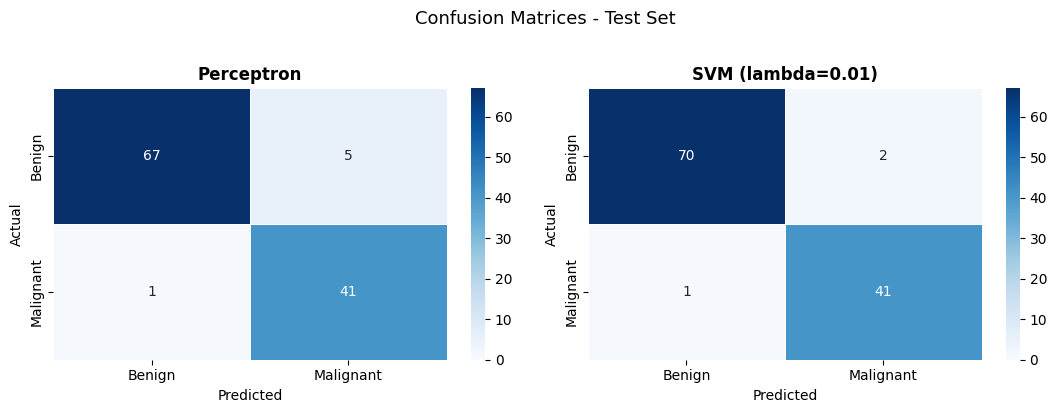

                                 Perceptron      SVM
Missed cancers (FN)                       1       1
Unnecessary alarms (FP)                   5       2
Malignant recall                     97.6%   97.6%


In [8]:
y_pred_svm = linear_classifier(X_test, theta_svm, theta0_svm).astype(int)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=[1, -1])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(axes, [cm_p, cm_svm], ['Perceptron', 'SVM (lambda=0.01)']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                ax=ax, linewidths=0.5, vmin=0, vmax=cm_p.max())
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices - Test Set', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"{'':30s} {'Perceptron':>12} {'SVM':>8}")
print(f"{'Missed cancers (FN)':30s} {cm_p[1,0]:>12}  {cm_svm[1,0]:>6}")
print(f"{'Unnecessary alarms (FP)':30s} {cm_p[0,1]:>12}  {cm_svm[0,1]:>6}")
print(f"{'Malignant recall':30s} {cm_p[1,1]/cm_p[1].sum():>11.1%}  {cm_svm[1,1]/cm_svm[1].sum():>6.1%}")

**Observation - Confusion matrix comparison**

The comparison reveals something more nuanced than the headline error rates suggest. Both models miss exactly 1 malignant tumour - the SVM does not improve cancer detection at all. What it does improve is specificity: false alarms drop from 5 to 2.

This makes sense given how the margin works. By pushing the boundary away from both classes, the SVM moves it further from the benign cluster, reducing the chance of a benign point being misclassified as malignant. The malignant cluster is tight and well-separated, so the single missed cancer is likely an outlier that sits on the wrong side regardless of where the boundary is drawn.

In clinical terms: the SVM gives fewer unnecessary follow-up tests with no loss in cancer detection. That is the practical value of the margin.

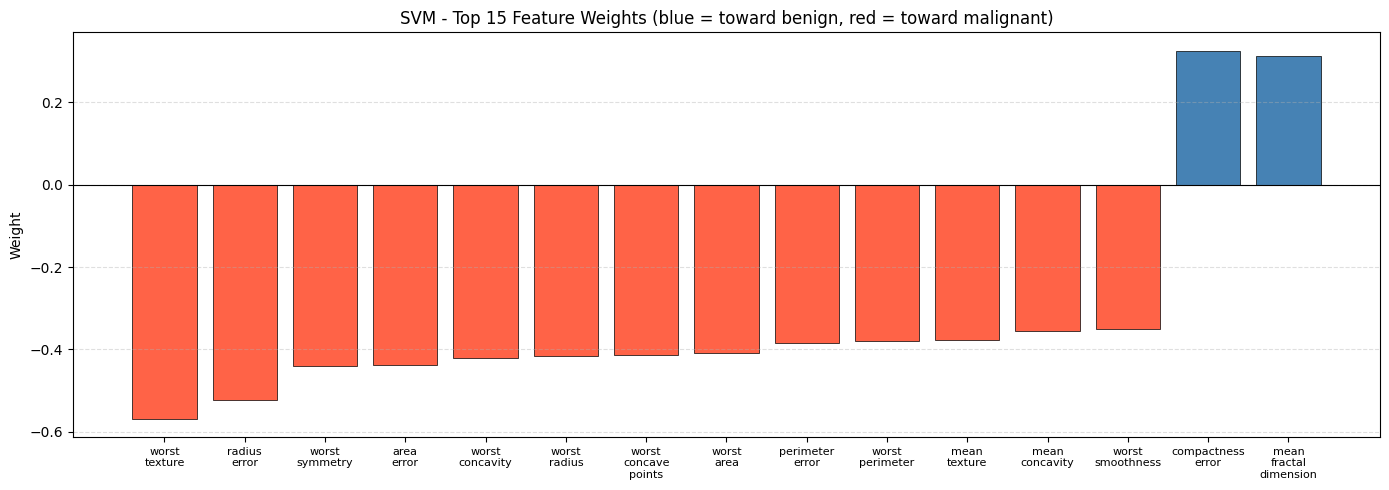

Top 5 features:
  worst texture                        w = -0.5682
  radius error                         w = -0.5218
  worst symmetry                       w = -0.4412
  area error                           w = -0.4391
  worst concavity                      w = -0.4220


In [9]:
feature_names = [name.replace(' ', '\n') for name in load_breast_cancer().feature_names]
importances = np.abs(theta_svm)
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if theta_svm[i] > 0 else 'tomato' for i in order[:15]]
ax.bar(range(15), theta_svm[order[:15]], color=colors, edgecolor='k', linewidth=0.5)
ax.set_xticks(range(15))
ax.set_xticklabels([feature_names[i] for i in order[:15]], fontsize=8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Weight')
ax.set_title('SVM - Top 15 Feature Weights (blue = toward benign, red = toward malignant)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout(); plt.show()

print("Top 5 features:")
for i in order[:5]:
    print(f"  {load_breast_cancer().feature_names[i]:35s}  w = {theta_svm[i]:+.4f}")

**Observation - Feature weights**

All five of the highest-weight features carry negative values, meaning they push the prediction toward malignant (-1). The features are worst texture, radius error, worst symmetry, area error, and worst concavity. A large value on any of these makes the model more confident the tumour is malignant.

This is clinically coherent. Malignant tumours tend to be larger (radius, area), more irregular in shape (symmetry, concavity), and have rougher surface texture. The "worst" prefix in the feature names refers to the mean of the three largest values across cell nuclei - essentially capturing the most extreme cells in the sample, which are precisely the ones that distinguish malignant tissue.

Features with small absolute weights - likely redundant measurements or ones that do not separate the classes linearly - are effectively ignored. The SVM has learned a sparse representation even without an explicit sparsity penalty.

### 4.4 Effect of Regularisation (λ)

λ=0.0001  train=0.88%  test=3.51%  margin=0.654


λ=0.01    train=1.32%  test=2.63%  margin=1.110
λ=0.1     train=1.76%  test=3.51%  margin=2.171


λ=1.0     train=3.74%  test=4.39%  margin=4.761


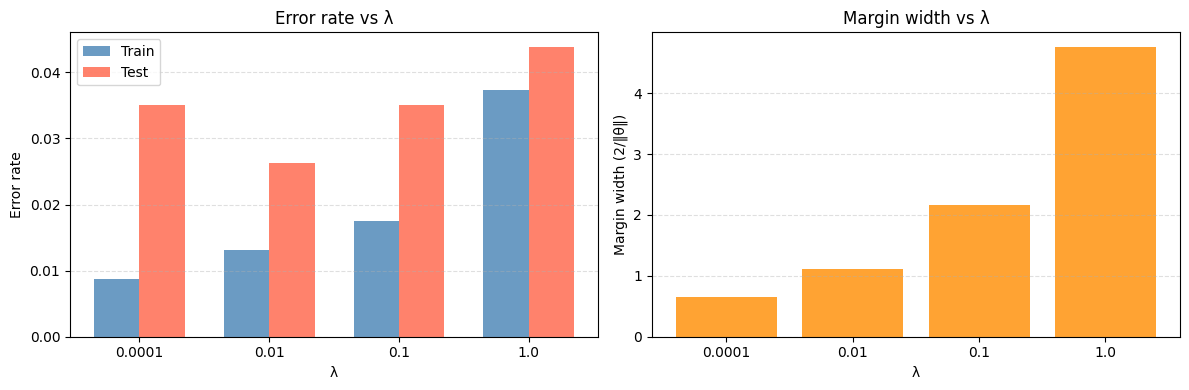

In [10]:
lambdas = [0.0001, 0.01, 0.1, 1.0]
results = []
for lam in lambdas:
    th, th0, _, tr, te = svm_sgd(X_train, y_train, X_test, y_test, lam=lam, eta=0.005, T=100)
    results.append((lam, tr[-1], te[-1], 2/np.linalg.norm(th)))
    print(f'λ={lam:<6}  train={tr[-1]:.2%}  test={te[-1]:.2%}  margin={2/np.linalg.norm(th):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(lambdas)); w = 0.35
lam_labels = [str(l) for l in lambdas]

axes[0].bar(x-w/2, [r[1] for r in results], w, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x+w/2, [r[2] for r in results], w, label='Test',  color='tomato',    alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(lam_labels)
axes[0].set_xlabel('λ'); axes[0].set_ylabel('Error rate')
axes[0].set_title('Error rate vs λ'); axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4, axis='y')

axes[1].bar(x, [r[3] for r in results], color='darkorange', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(lam_labels)
axes[1].set_xlabel('λ'); axes[1].set_ylabel('Margin width (2/‖θ‖)')
axes[1].set_title('Margin width vs λ')
axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout(); plt.show()

**Observation — Effect of λ**

The two charts tell the classic regularisation story clearly.

In the error chart: at very low λ (0.0001) the training error is minimal but the test error is slightly elevated — the model has memorised the training set too closely and doesn't generalise as well. As λ increases the training error rises, but the test error initially *drops* before rising again at λ=1.0. The sweet spot where both are lowest is around λ=0.01.

In the margin chart: margin width grows monotonically with λ, which makes sense mathematically — a larger penalty on ‖θ‖ forces the weights to be smaller, which directly widens the margin (2/‖θ‖). But a very wide margin means the boundary can't fit tightly enough to the data, causing more errors.

The key practical takeaway: λ is not a knob you set once — it needs to be tuned, typically via cross-validation, because the right value depends on how separable the data is.

---
## 5. Results

| Method | Train error | Test error | Missed cancers | False alarms | Malignant recall |
|--------|-------------|------------|---------------|--------------|-----------------|
| Perceptron | 2.20% | 5.26% | 1 | 5 | 97.6% |
| SVM (lambda=0.01) | 1.32% | 2.63% | 1 | 2 | 97.6% |

**What the numbers tell us:**
- Both algorithms achieve the same malignant recall (97.6%) - the improvement in overall accuracy from Perceptron to SVM comes entirely from fewer false alarms (5 → 2), not better cancer detection
- The Perceptron converges in ~3 epochs. Its boundary stops wherever the last correction left it - close enough to the benign cluster to generate false alarms
- The SVM's margin explicitly pushes the boundary away from both classes, which is why it produces fewer false alarms on the test set
- At lambda=0.0001 the SVM overfits: train error drops to 0.88% but test error rises to 3.51%. At lambda=1.0 the margin is too wide and accuracy falls for both sets
- The best lambda on this dataset is 0.01 - the margin is wide enough to generalise but not so wide that it misclassifies training examples
- Feature weights show that worst texture, radius error, worst symmetry, area error, and worst concavity are the five features driving the boundary - all carry negative weights (toward malignant), consistent with known tumour biology

---
## 6. Limitations

**Perceptron**
- Only guaranteed to converge if the data is **linearly separable** — on noisy real data it may cycle forever
- The boundary it finds depends on the order examples are seen and the initialisation — there is no unique solution
- Has no notion of margin — it accepts any separating hyperplane, even one very close to the data

**Linear classifiers generally**
- Cannot learn **non-linear decision boundaries** — if the true boundary is curved, a linear model will always underfit regardless of how much data you have
- Sensitive to **feature scaling** — features with large ranges dominate the dot product, which is why standardisation is essential
- **Binary only** by default — multi-class requires one-vs-rest or one-vs-one wrappers, which adds complexity
- The **Perceptron convergence theorem** only holds for linearly separable data; real datasets are rarely perfectly separable

**SVM with SGD**
- The quality of the solution depends heavily on the choice of **learning rate η** and **regularisation λ** — both require tuning
- SGD introduces noise; the objective oscillates rather than converging smoothly, making it harder to know when to stop
- Does not produce **probability estimates** natively — you only get a hard class label, not a confidence score